In [79]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import streamlit as st 
import os 
import sys
sys.path.insert(1, r'D:\Notebooks\LLM\env')
from enviorment import load_env
import os 
from langchain_google_genai import ChatGoogleGenerativeAI
load_env()
from langchain_community.tools.tavily_search import TavilySearchResults
from typing import TypedDict,Annotated,Literal
from pydantic import BaseModel, Field
import operator
from langgraph.graph import StateGraph,START, END,MessagesState

from langgraph.types import Command
from langgraph.checkpoint.memory import InMemorySaver
# model=ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash-lite",   # or gemini-2.0-pro, 1.5-pro, etc.
#     temperature=0.2)
#from langchain_core.messages.utils import trim_messages,count_tokens_approximately
model=ChatOpenAI()

In [80]:
from textwrap import dedent

SYSTEM_PROMPT = dedent("""
    You are a coding assistant.
    Help the user implement code changes safely and clearly.
    When needed, use available tools to inspect files, run commands, and verify results.
    Before making changes, briefly state what you will do.
    After changes, summarize what was changed and why.
""") 
                    

In [81]:
SYSTEM_PROMPT

'\nYou are a coding assistant.\nHelp the user implement code changes safely and clearly.\nWhen needed, use available tools to inspect files, run commands, and verify results.\nBefore making changes, briefly state what you will do.\nAfter changes, summarize what was changed and why.\n'

In [82]:
import json
with open(r'D:\Notebooks\Langraph\agents\Skills\skills\mcp_config.json', "r") as f:
        config = json.load(f)
servers =config.get("mcpServers", {})
for _, server in servers.items():
        if "command" in server and "transport" not in server:
            server["transport"] = "stdio"
        if "url" in server and "transport" not in server:
            server["transport"] = "streamable_http"

In [87]:
from langchain_mcp_adapters.client import MultiServerMCPClient
client = MultiServerMCPClient(servers)
mcp_tools = await client.get_tools()

In [92]:
blocked_tools = ["list_releases", "list_issues", "list_branches"]

filtered_tools = [
    tool for tool in mcp_tools
    if tool.name not in blocked_tools
]

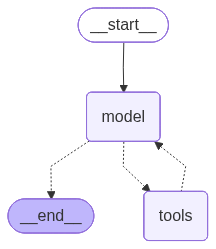

In [94]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from textwrap import dedent
from IPython.display import Image, display

mcp_agent = create_agent(
    model,
    system_prompt=SYSTEM_PROMPT,
    tools=filtered_tools,
)

display(Image(mcp_agent.get_graph(xray=True).draw_mermaid_png()))

In [90]:
TEST_PROMPT="""Use my authenticated GitHub account.

First, call the repository listing tool and retrieve my repositories.
Only use the exact repository names returned by the tool.

Select the 3 most recently updated repositories from that list.
Do NOT invent, guess, or modify repository names.
Do NOT call issues or releases APIs.

Based only on those repositories, infer what I'm focusing on lately.

Respond in one paragraph."""

In [95]:
messages = await mcp_agent.ainvoke({"messages": [TEST_PROMPT]})
for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

Use my authenticated GitHub account.

First, call the repository listing tool and retrieve my repositories.
Only use the exact repository names returned by the tool.

Select the 3 most recently updated repositories from that list.
Do NOT invent, guess, or modify repository names.
Do NOT call issues or releases APIs.

Based only on those repositories, infer what I'm focusing on lately.

Respond in one paragraph.
================================== Ai Message ==================================
Tool Calls:
  get_me (call_x82nSQlty4YlQNCy3HEvKk0m)
 Call ID: call_x82nSQlty4YlQNCy3HEvKk0m
  Args:
================================= Tool Message =================================
Name: get_me

{"login":"dharmsingh4u","id":55612171,"profile_url":"https://github.com/dharmsingh4u","avatar_url":"https://avatars.githubusercontent.com/u/55612171?v=4","details":{"public_repos":8,"public_gists":0,"followers":0,"following":0

In [61]:
messages['messages'][-1].content

'Based on your three most recently updated repositories, it seems you are currently focusing on Python programming, data analysis, and machine learning. The repositories "Python," "Data-Study," and "LMM" show activity in Python, Jupyter Notebook, and machine learning study. This indicates a focus on data analysis and machine learning projects using Python and Jupyter Notebook for experimentation and study purposes.'

In [97]:
from langchain_core.messages import HumanMessage,AIMessage

In [100]:
chunk= {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 5298, 'total_tokens': 5308, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DSPP7KS0Mbp3e9KvqY0RBaCeGzBTm', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d6dc6-4f3f-7910-b287-3b565b53a6ea-0', tool_calls=[{'name': 'get_me', 'args': {}, 'id': 'call_AaNWhGuZbmsx4G0YUCVaGFNY', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 5298, 'output_tokens': 10, 'total_tokens': 5308, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}

In [113]:
chunk.get("model")

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 5298, 'total_tokens': 5308, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DSPP7KS0Mbp3e9KvqY0RBaCeGzBTm', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d6dc6-4f3f-7910-b287-3b565b53a6ea-0', tool_calls=[{'name': 'get_me', 'args': {}, 'id': 'call_AaNWhGuZbmsx4G0YUCVaGFNY', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 5298, 'output_tokens': 10, 'total_tokens': 5308, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [112]:
token

[AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 5298, 'total_tokens': 5308, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DSPP7KS0Mbp3e9KvqY0RBaCeGzBTm', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d6dc6-4f3f-7910-b287-3b565b53a6ea-0', tool_calls=[{'name': 'get_me', 'args': {}, 'id': 'call_AaNWhGuZbmsx4G0YUCVaGFNY', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 5298, 'output_tokens': 10, 'total_tokens': 5308, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]

In [111]:
full_response = ""
token = chunk.get("model")['messages'] or chunk.get("model")['messages'] or ""
full_response += token

TypeError: can only concatenate str (not "list") to str

In [105]:
full_response

''